# Strategy 11 — VWAP Intraday Mean Reversion

End-to-end backtest of the strategy documented in [`DocumentationVault/strategies/11_VWAP_Intraday_Reversion.md`](../DocumentationVault/strategies/11_VWAP_Intraday_Reversion.md).

The notebook follows the same six-section template as the SMA / RSI baselines:

1. Load data
2. Multi-timeframe preparation
3. Strategy definition + baseline backtest
4. Walk-Forward Optimization (5 folds, 75 % IS / 25 % OOS)
5. Robustness — Monte Carlo, block bootstrap, sub-period, parameter sensitivity
6. Takeaways

**Scope deviations from the doc.** The strategy doc lists b3, crypto as target markets; crypto is not present in `data/` so the notebook runs on **b3** only.


**Scope deviations from the doc.**
- B3 only — Crypto is listed in the doc but the repo has no `data/crypto/`.
- 1min timeframe **dropped** from the baseline for WFO cost reasons; user can re-add via `GROUP_TIMEFRAMES`.
- The **dynamic VWAP-touch TP** is **approximated** by a fixed ATR-based TP (`tp_atr_mult × ATR_stop`) — true VWAP-touch needs a custom `Backtester` exit hook.
- `tick_vol` is used as the volume weight (no actual contract-volume data on this dataset, same caveat as the doc).

**Note:** The notebook is committed *unexecuted* — run it via Jupyter / VS Code (or `jupyter nbconvert --to notebook --execute --inplace`) to populate the outputs.

In [1]:
import gc
import sys
from pathlib import Path
from collections import Counter

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from source import (
    discover_datasets, build_lazy_grid, LazyDataset,
    VWAPReversionStrategy, VWAPReversionParams,
    Backtester, compute_metrics,
    plot_backtest_dashboard, plot_wfo_dashboard, plot_robustness_dashboard,
    walk_forward, WFOResult,
    monte_carlo_trades, monte_carlo_summary,
    block_bootstrap_trades, subperiod_analysis, parameter_sensitivity,
    run_backtest_grid, run_backtests_with_params, run_wfo_grid,
    reshape_grid_results, cpu_count,
)


N_JOBS = "auto"
print(f"Parallelism budget: n_jobs={N_JOBS!r} (cpu_count={cpu_count()})")

Parallelism budget: n_jobs='auto' (cpu_count=15)


## 1. Load the data

Metadata-only discovery — no CSV is read until each `LazyDataset.load()` fires (which happens inside worker processes, not in the parent).

In [2]:
metas = discover_datasets(REPO_ROOT / "data")
print(f"Discovered {len(metas)} dataset(s):")
for (asset, tf), meta in metas.items():
    tag = f"[{meta.group}]" if meta.group else "[root]"
    print(f"  {tag:8s} {asset:10s} {tf:4s}  {meta.start.date()} -> {meta.end.date()}")

target_groups = {'crypto', 'b3'}
present_groups = {m.group for m in metas.values()}
missing = sorted(target_groups - present_groups)
if missing:
    print(f"\n[note] Strategy targets {sorted(target_groups)} but no data present for: {missing}. Continuing with: {sorted(target_groups & present_groups)}.")

Discovered 58 dataset(s):
  [b3]     ABEV3      M1    2021-05-17 -> 2026-05-15
  [b3]     BBAS3      M1    2021-05-17 -> 2026-05-15
  [b3]     BBDC3      M1    2021-05-17 -> 2026-05-15
  [b3]     BBSE3      M1    2021-05-17 -> 2026-05-15
  [b3]     BRAV3      M1    2021-05-17 -> 2026-05-15
  [b3]     CMIG3      M1    2021-05-17 -> 2026-05-15
  [b3]     CMIN3      M1    2021-05-17 -> 2026-05-15
  [b3]     CXSE3      M1    2021-05-17 -> 2026-05-15
  [b3]     EQTL3      M1    2021-05-17 -> 2026-05-15
  [b3]     HYPE3      M1    2021-05-17 -> 2026-05-15
  [b3]     ITSA3      M1    2021-05-17 -> 2026-05-15
  [b3]     ITSA4      M1    2021-05-17 -> 2026-05-15
  [b3]     MGLU3      M1    2021-05-17 -> 2026-05-15
  [b3]     PETR3      M1    2021-05-17 -> 2026-05-15
  [b3]     PETR4      M1    2021-05-17 -> 2026-05-15
  [b3]     POMO4      M1    2021-05-17 -> 2026-05-15
  [b3]     PRIO3      M1    2021-05-17 -> 2026-05-15
  [b3]     RECV3      M1    2021-05-17 -> 2026-05-15
  [b3]     SUZB3    

## 2. Multi-timeframe preparation

Per-group target timeframes (matching the doc's "Markets" / "Timeframes" sections):

- **B3** — 5min, 15min

`build_lazy_grid` returns `{group: {tf: {asset: LazyDataset}}}` without loading any CSV; workers materialise frames one cell at a time.

In [3]:
GROUP_TIMEFRAMES = {
    "b3": [
        "5min",
        "15min"
    ]
}

group_tfs = build_lazy_grid(REPO_ROOT / "data", group_timeframes=GROUP_TIMEFRAMES)
group_tfs = {g: tfs for g, tfs in group_tfs.items() if g in GROUP_TIMEFRAMES}
if not present_groups & set(GROUP_TIMEFRAMES):
    raise RuntimeError("None of the strategy's target groups have local data.")

for group, tfs in group_tfs.items():
    print(f"\n{group.upper()}:")
    for tf, assets in tfs.items():
        print(f"  {tf:6s}  assets={list(assets)}")


B3:
  5min    assets=['ABEV3', 'BBAS3', 'BBDC3', 'BBSE3', 'BRAV3', 'CMIG3', 'CMIN3', 'CXSE3', 'EQTL3', 'HYPE3', 'ITSA3', 'ITSA4', 'MGLU3', 'PETR3', 'PETR4', 'POMO4', 'PRIO3', 'RECV3', 'SUZB3', 'UGPA3', 'VIVT3', 'WDO', 'WIN']
  15min   assets=['ABEV3', 'BBAS3', 'BBDC3', 'BBSE3', 'BRAV3', 'CMIG3', 'CMIN3', 'CXSE3', 'EQTL3', 'HYPE3', 'ITSA3', 'ITSA4', 'MGLU3', 'PETR3', 'PETR4', 'POMO4', 'PRIO3', 'RECV3', 'SUZB3', 'UGPA3', 'VIVT3', 'WDO', 'WIN']


## 3. Strategy definition — VWAP Intraday Mean Reversion

**VWAP** is computed cumulatively from session start (resets each trading day) using typical price `(H+L+C)/3` weighted by `tick_vol`. A volume-weighted variance gives the **VWAP std**, and bands sit `n_sigma` standard deviations either side of VWAP.

**Entry (intraday, B3)**
- Long when `close <= VWAP_lower`, after the warmup bars, before the entry cutoff.
- Short when `close >= VWAP_upper`.

**Exit (via Backtester)**
- Hard SL/TP at `entry ± atr_mult × ATR_entry` — TP approximates the doc's dynamic VWAP-touch target.
- Session-end forced close via Backtester (`session_start`/`session_end` defaults are `9` and `18` for B3).
- Opposite band touch reverses the position via signal reversal.

Per-group baseline parameters:

| Parameter | Default |
|-----------|---------|
| `n_sigma` | `2.0` |
| `atr_period` | `14` |
| `sl_atr_mult` | `2.0` |
| `tp_atr_mult` | `1.5` |
| `vwap_warmup_bars` | `10` |
| `entry_cutoff_minutes` | `30` |

In [4]:
baseline_params = VWAPReversionParams(n_sigma=2.0, atr_period=14, sl_atr_mult=2.0, tp_atr_mult=1.5, vwap_warmup_bars=10, entry_cutoff_minutes=30)

SUMMARY_METRICS = [
    "num_trades", "total_pnl", "win_rate", "profit_factor",
    "expectancy", "max_drawdown", "sharpe_daily", "sharpe_per_trade", "p_value",
]


class _PortfolioResult:
    def __init__(self, trades, equity):
        self.trades = trades
        self.equity = equity


def build_portfolio(per_asset_results):
    frames = []
    for asset, result in per_asset_results.items():
        if not result.trades.empty:
            t = result.trades.copy()
            t.insert(0, "asset", asset)
            frames.append(t)
    if not frames:
        return _PortfolioResult(pd.DataFrame(), pd.Series(dtype=float))
    combined = (pd.concat(frames, ignore_index=True)
                .sort_values("exit_time").reset_index(drop=True))
    equity = pd.Series(combined["pnl_points"].cumsum().values,
                       index=pd.to_datetime(combined["exit_time"].values),
                       name="equity_points")
    return _PortfolioResult(combined, equity)


def metrics_comparison(portfolio_dict, keys=None):
    keys = keys or SUMMARY_METRICS
    rows = {}
    for tf, portfolio in portfolio_dict.items():
        m = compute_metrics(portfolio)
        rows[tf] = {k: m[k] for k in keys if k in m}
    return pd.DataFrame(rows)


In [5]:
flat_results = run_backtest_grid(
    group_tfs, baseline_params,
    strategy_cls=VWAPReversionStrategy, n_jobs=N_JOBS,
)
baseline_per_asset = reshape_grid_results(flat_results)
baseline_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in baseline_per_asset.items()
}

for group in baseline_portfolio:
    for tf, portfolio in baseline_portfolio[group].items():
        n = len(portfolio.trades) if not portfolio.trades.empty else 0
        print(f"{group:5s}  {tf:6s}  {n:>6,} trades")

  backtest [46/46]
b3     5min    55,955 trades
b3     15min   21,045 trades


### 3.1 B3 — baseline across timeframes

Portfolio metrics across timeframes, per-asset breakdown, and equity dashboards.

Portfolio metrics — B3 (all assets, per timeframe):


,5min,15min
num_trades,55955.000000,21045.000000
total_pnl,-21331.070286,34020.608143
win_rate,0.604647,0.593775
profit_factor,0.979350,1.069367
expectancy,-0.381218,1.616565
max_drawdown,-47145.592607,-25816.757429
sharpe_daily,-0.223706,0.416644
sharpe_per_trade,-0.617014,1.111429
p_value,0.537226,0.266384



Per-asset breakdown by timeframe:

  5min:


,ABEV3,BBAS3,BBDC3,BBSE3,BRAV3,CMIG3,CMIN3,CXSE3,EQTL3,HYPE3,...,PETR3,PETR4,POMO4,PRIO3,RECV3,SUZB3,UGPA3,VIVT3,WDO,WIN
num_trades,2112.000000,2203.000000,2231.000000,2265.000000,2394.000000,2625.000000,2387.000000,2357.000000,2342.000000,2321.000000,...,2318.000000,2343.000000,2728.000000,2331.000000,2210.000000,2141.000000,2279.000000,2217.000000,3245.000000,3969.000000
total_pnl,11.442857,4.436786,9.852500,15.246071,-11.783571,6.207500,8.872500,10.202857,20.135357,-0.895357,...,-4.323929,-11.895714,12.636786,-9.989286,20.101429,33.492500,13.585000,6.660714,100.242929,-21579.071429
sharpe_daily,1.437106,0.407594,1.222281,1.261121,-0.359062,0.968370,2.143078,1.556796,1.060665,-0.026467,...,-0.226005,-0.759132,3.133225,-0.293497,1.288954,1.067868,1.041069,0.507498,0.071851,-0.229258
profit_factor,1.207438,1.050214,1.166119,1.167921,0.957069,1.123638,1.296654,1.217036,1.135398,0.994904,...,0.970986,0.907866,1.503200,0.963659,1.186586,1.147953,1.131048,1.069908,1.004046,0.978541
max_drawdown,-2.000000,-4.975000,-1.750000,-1.956786,-18.388929,-2.335714,-0.790357,-1.503929,-4.882500,-11.421071,...,-14.608214,-14.163214,-0.697857,-16.791429,-2.341429,-7.074643,-2.618214,-4.956071,-1162.475536,-47162.178571



  15min:


,ABEV3,BBAS3,BBDC3,BBSE3,BRAV3,CMIG3,CMIN3,CXSE3,EQTL3,HYPE3,...,PETR3,PETR4,POMO4,PRIO3,RECV3,SUZB3,UGPA3,VIVT3,WDO,WIN
num_trades,798.000000,837.000000,814.000000,909.000000,906.000000,1028.000000,943.000000,894.000000,857.000000,882.000000,...,791.000000,834.000000,964.000000,878.000000,836.000000,858.000000,842.000000,862.000000,1216.000000,1354.000000
total_pnl,11.906429,-0.036071,6.715000,3.102143,-18.595000,2.106786,3.456071,0.928571,20.717857,6.320357,...,-9.590357,-10.513571,3.721071,-10.028929,7.832500,18.448571,13.055000,9.037143,-161.556500,34103.928571
sharpe_daily,1.730783,-0.000737,0.936759,0.278489,-0.595234,0.299365,0.918160,0.159347,1.176253,0.299387,...,-0.566218,-0.727444,1.013309,-0.316464,0.536250,0.603004,1.013645,0.747499,-0.065779,0.422076
profit_factor,1.429392,0.999307,1.217103,1.053589,0.888151,1.058153,1.198039,1.030885,1.263677,1.062051,...,0.883018,0.855832,1.237812,0.938397,1.116473,1.125703,1.228726,1.162919,0.987730,1.071688
max_drawdown,-1.449286,-4.008214,-2.176786,-4.428214,-20.375000,-1.927143,-0.815000,-2.098571,-2.328214,-9.619286,...,-11.285714,-13.783214,-0.890000,-13.975357,-3.393929,-7.278929,-2.584286,-2.765000,-1237.022643,-25740.928571


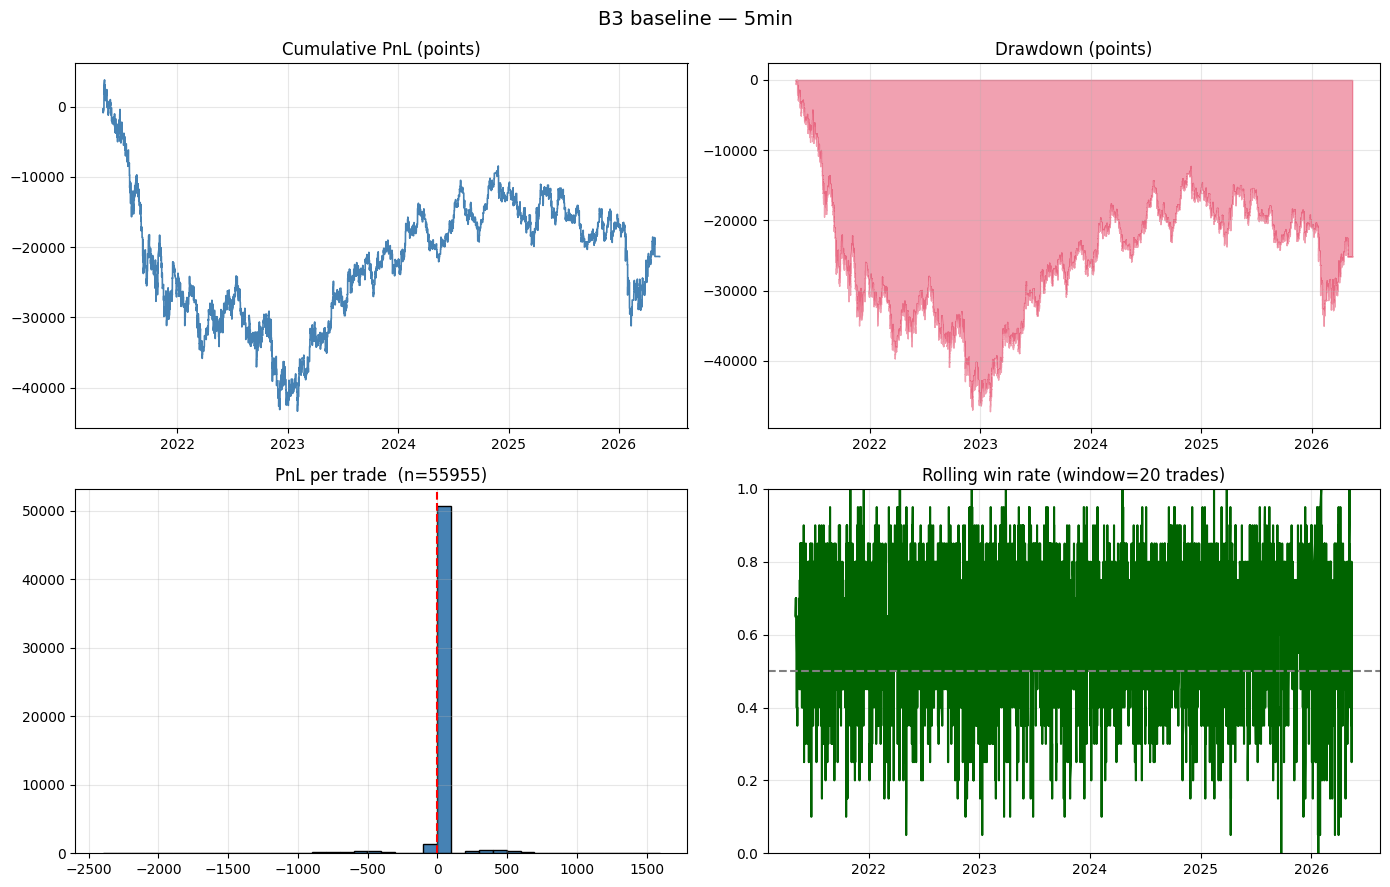

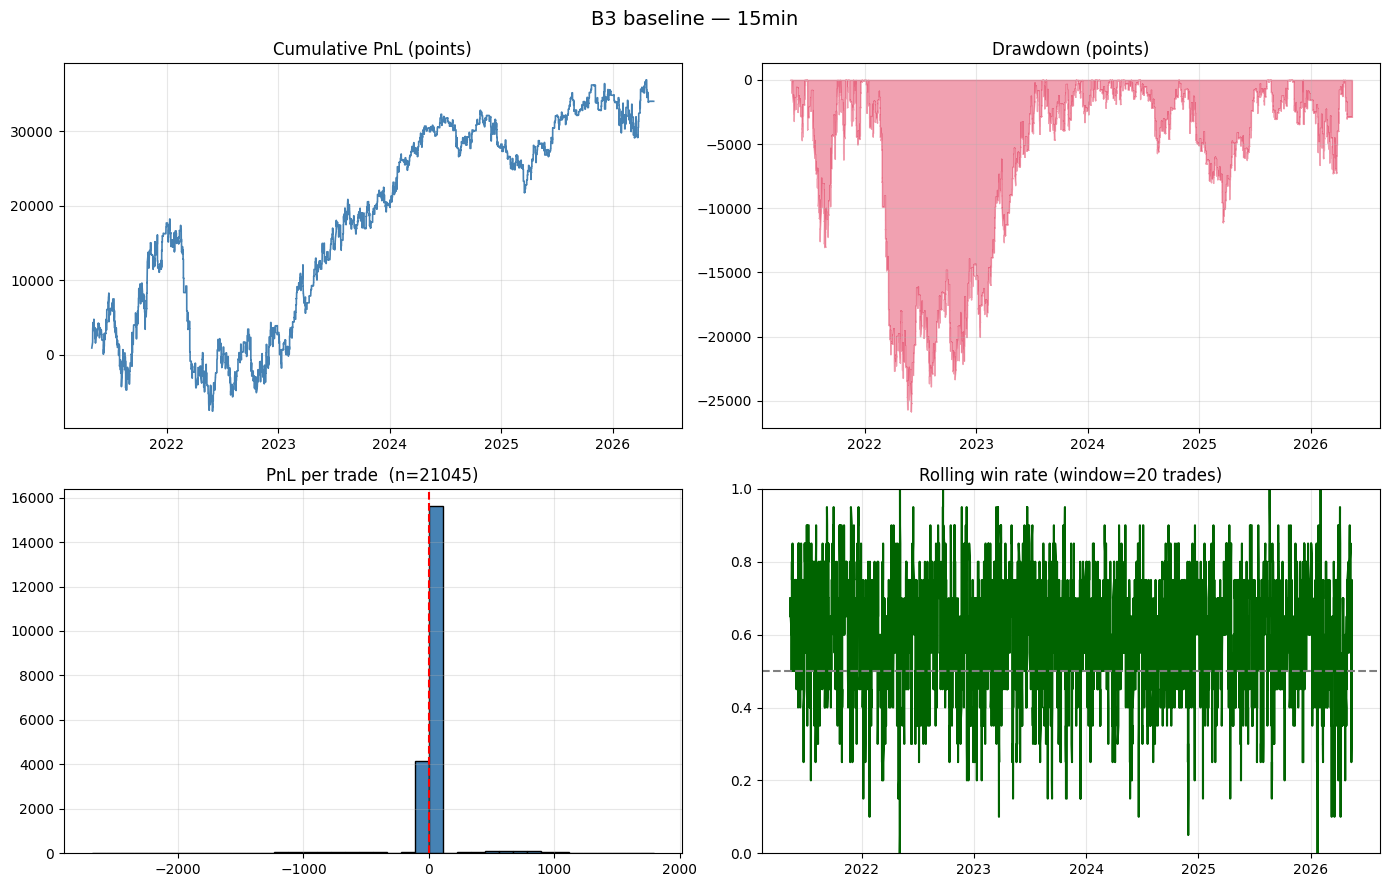

In [6]:
if "b3" in baseline_portfolio:
    print("Portfolio metrics — B3 (all assets, per timeframe):")
    display(metrics_comparison(baseline_portfolio["b3"]))
    print("\nPer-asset breakdown by timeframe:")
    for tf, asset_results in baseline_per_asset["b3"].items():
        print(f"\n  {tf}:")
        detail = {asset: compute_metrics(r) for asset, r in asset_results.items()}
        display(pd.DataFrame(detail).loc[
            ["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "max_drawdown"]
        ])
    for tf, portfolio in baseline_portfolio["b3"].items():
        if portfolio.trades.empty:
            print(f"  {tf}: no trades — skipping")
            continue
        fig = plot_backtest_dashboard(portfolio, title=f"B3 baseline — {tf}")
        plt.show()

## 4. Walk-Forward Optimization

Each (b3, timeframe, asset) runs an independent WFO with `n_splits=5` and `oos_ratio=0.25`. In-sample objective: maximize daily Sharpe.

WFO grid:

| Parameter | Values |
|-----------|--------|
| `n_sigma` | [1.5, 2.0, 2.5, 3.0] |
| `sl_atr_mult` | [1.5, 2.0, 2.5] |
| `vwap_warmup_bars` | [5, 10, 20] |
| `entry_cutoff_minutes` | [15, 30, 60] |

In [ ]:
param_grid = {
    "n_sigma": [
        1.5,
        2.0,
        2.5,
        3.0
    ],
    "sl_atr_mult": [
        1.5,
        2.0,
        2.5
    ],
    "vwap_warmup_bars": [
        5,
        10,
        20
    ],
    "entry_cutoff_minutes": [
        15,
        30,
        60
    ]
}


def build_combined_wfo(wfo_per_asset_tf):
    _oos_frames = []
    for asset, wfo in wfo_per_asset_tf.items():
        if not wfo.oos_trades.empty:
            t = wfo.oos_trades.copy()
            t.insert(0, "asset", asset)
            _oos_frames.append(t)
    if not _oos_frames:
        return WFOResult(windows=pd.DataFrame(),
                         oos_equity=pd.Series(dtype=float),
                         oos_trades=pd.DataFrame())
    combined_oos = (pd.concat(_oos_frames, ignore_index=True)
                    .sort_values("exit_time").reset_index(drop=True))
    oos_equity = pd.Series(combined_oos["pnl_points"].cumsum().values,
                           index=pd.to_datetime(combined_oos["exit_time"].values),
                           name="equity_points")
    sample_wfo = next(iter(wfo_per_asset_tf.values()))
    fold_rows = []
    if "fold" in combined_oos.columns and not sample_wfo.windows.empty:
        fold_nums = sorted(combined_oos["fold"].unique())
        avg_deg = {}
        for fn in fold_nums:
            degs = []
            for wfo in wfo_per_asset_tf.values():
                if wfo.windows.empty or "degradation_ratio" not in wfo.windows.columns:
                    continue
                fw = wfo.windows[wfo.windows["fold"] == fn]
                if not fw.empty and pd.notna(fw.iloc[0]["degradation_ratio"]):
                    degs.append(float(fw.iloc[0]["degradation_ratio"]))
            avg_deg[fn] = float(np.nanmean(degs)) if degs else np.nan
        for fold_num in fold_nums:
            _ft = combined_oos[combined_oos["fold"] == fold_num].sort_values("exit_time")
            _feq = pd.Series(_ft["pnl_points"].cumsum().values,
                             index=pd.to_datetime(_ft["exit_time"].values))
            _fm = compute_metrics(_PortfolioResult(_ft, _feq))
            _bnd = sample_wfo.windows[sample_wfo.windows["fold"] == fold_num].iloc[0]
            param_cols = {k: v for k, v in _bnd.items() if str(k).startswith("param_")}
            fold_rows.append({
                "fold": fold_num,
                "is_start": _bnd["is_start"],  "is_end": _bnd["is_end"],
                "oos_start": _bnd["oos_start"], "oos_end": _bnd["oos_end"],
                "oos_pnl": _fm["total_pnl"], "oos_sharpe": _fm["sharpe_daily"],
                "oos_profit_factor": _fm["profit_factor"],
                "oos_win_rate": _fm["win_rate"], "oos_trades": _fm["num_trades"],
                "degradation_ratio": avg_deg.get(fold_num, np.nan),
                **param_cols,
            })
    return WFOResult(windows=pd.DataFrame(fold_rows),
                     oos_equity=oos_equity,
                     oos_trades=combined_oos)


flat_wfo = run_wfo_grid(
    group_tfs, param_grid=param_grid,
    n_splits=5, oos_ratio=0.25,
    strategy_cls=VWAPReversionStrategy, params_cls=VWAPReversionParams,
    n_jobs=N_JOBS, inner_n_jobs=1,
)
wfo_per_asset = reshape_grid_results(flat_wfo)
wfo_combined = {
    g: {tf: build_combined_wfo(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in wfo_per_asset.items()
}

for group in wfo_combined:
    for tf, wfo in wfo_combined[group].items():
        print(f"{group:5s}  {tf:6s}  {len(wfo.oos_trades):>6,} OOS trades")

### 4.1 B3 — WFO out-of-sample

In [ ]:
if "b3" in wfo_combined:
    oos_ports = {tf: _PortfolioResult(w.oos_trades, w.oos_equity)
                  for tf, w in wfo_combined["b3"].items() if not w.oos_trades.empty}
    if oos_ports:
        print("OOS portfolio metrics — B3 (per timeframe):")
        display(metrics_comparison(oos_ports))
    for tf, wfo in wfo_combined["b3"].items():
        if wfo.oos_trades.empty:
            continue
        baseline_eq = baseline_portfolio["b3"][tf].equity
        fig = plot_wfo_dashboard(wfo, full_equity=baseline_eq)
        fig.suptitle(f"WFO — B3 {tf}", y=1.02)
        plt.show()

### 4.X WFO-optimized full-history backtest

Pick the most-frequent param combo across folds per (group, tf, asset), then run a full-history backtest with that combo.

In [ ]:
_INT_FIELDS = {'session_start', 'session_end', 'vwap_warmup_bars', 'entry_cutoff_minutes', 'atr_period'}


def pick_best_params(wfo_windows, fallback):
    if wfo_windows.empty:
        return fallback
    pcols = [c for c in wfo_windows.columns if c.startswith("param_")]
    tuples = [tuple(row[c] for c in pcols) for _, row in wfo_windows.iterrows()]
    best = Counter(tuples).most_common(1)[0][0]
    kw = {c.replace("param_", ""): v for c, v in zip(pcols, best)}
    for k in list(kw):
        if k in _INT_FIELDS:
            kw[k] = int(kw[k])
        else:
            try:
                kw[k] = float(kw[k])
            except (TypeError, ValueError):
                pass
    # Merge with fallback's full attrs so non-WFO params (e.g. session) are preserved
    base = fallback.as_dict()
    base.update(kw)
    return VWAPReversionParams(**base)


optimized_params = {}
params_by_key = {}
for group, tfs in wfo_per_asset.items():
    fallback = baseline_params
    optimized_params[group] = {}
    for tf, by_asset in tfs.items():
        optimized_params[group][tf] = {}
        for asset, wfo in by_asset.items():
            p = pick_best_params(wfo.windows, fallback)
            optimized_params[group][tf][asset] = p
            params_by_key[(group, tf, asset)] = p

flat_opt = run_backtests_with_params(
    group_tfs, params_by_key,
    strategy_cls=VWAPReversionStrategy, n_jobs=N_JOBS, progress=False,
)
opt_per_asset = reshape_grid_results(flat_opt)
optimized_portfolio = {
    g: {tf: build_portfolio(by_asset) for tf, by_asset in tfs.items()}
    for g, tfs in opt_per_asset.items()
}

for group in optimized_portfolio:
    print(f"Optimized full-history portfolio metrics — {group.upper()}:")
    display(metrics_comparison(optimized_portfolio[group]))
    opt_rows = []
    for tf, by_asset in optimized_params[group].items():
        for asset, params in by_asset.items():
            row = {"tf": tf, "asset": asset}
            row.update({k: v for k, v in params.as_dict().items() if k in ['n_sigma', 'sl_atr_mult', 'vwap_warmup_bars', 'entry_cutoff_minutes'] })
            opt_rows.append(row)
    if opt_rows:
        print(f"\nWFO-picked params per (TF, asset) — {group.upper()}:")
        display(pd.DataFrame(opt_rows).set_index(["tf", "asset"]))

## 5. Robustness

For each group, the timeframe with the highest OOS daily Sharpe (from §4) is selected automatically for robustness:
1. Monte-Carlo trade-order shuffling (1,000 runs)
2. Block bootstrap (1,000 runs)
3. Sub-period analysis (annual)
4. Parameter sensitivity — one-at-a-time sweeps around the WFO-picked params

In [ ]:
def best_oos_tf(group):
    best_tf_name, best_sharpe = None, -np.inf
    for tf, wfo in wfo_combined[group].items():
        if wfo.oos_trades.empty:
            continue
        port = _PortfolioResult(wfo.oos_trades, wfo.oos_equity)
        m = compute_metrics(port)
        s = m.get("sharpe_daily", np.nan)
        if not np.isnan(s) and s > best_sharpe:
            best_sharpe = s
            best_tf_name = tf
    return best_tf_name, best_sharpe


best_tfs = {g: best_oos_tf(g)[0] for g in group_tfs}
print("Selected best-OOS timeframes for robustness:", best_tfs)

variations = {
    "n_sigma": [
        1.5,
        2.0,
        2.5,
        3.0
    ],
    "sl_atr_mult": [
        1.5,
        2.0,
        2.5
    ],
    "vwap_warmup_bars": [
        5,
        10,
        20
    ],
    "entry_cutoff_minutes": [
        15,
        30,
        60
    ]
}

mc_results = {}
bootstrap_results = {}
subperiod_results = {}
sensitivity_results = {}

for group, tf in best_tfs.items():
    if tf is None:
        print(f"  [skip] {group}: no positive-Sharpe OOS TF")
        continue
    opt_port = optimized_portfolio[group][tf]
    if opt_port.trades.empty:
        print(f"  [skip] {group} {tf}: no optimized trades")
        continue
    print(f"\nRobustness — {group} {tf}  ({len(opt_port.trades)} trades)")

    mc = monte_carlo_trades(opt_port.trades, n_runs=1000, seed=42)
    mc_results[group] = (mc, monte_carlo_summary(mc))
    print("  monte carlo:", {k: round(v, 4) for k, v in mc_results[group][1].items()})

    bs = block_bootstrap_trades(opt_port.trades, n_runs=1000, seed=42)
    bootstrap_results[group] = (bs, monte_carlo_summary(bs))
    print("  block bootstrap:", {k: round(v, 4) for k, v in bootstrap_results[group][1].items()})

    subperiod_results[group] = subperiod_analysis(opt_port.trades, freq="YE")

    asset0 = next(iter(group_tfs[group][tf]))
    base_p = optimized_params[group][tf][asset0]
    with group_tfs[group][tf][asset0].using() as df0:
        sensitivity_results[group] = parameter_sensitivity(
            df0, base_p, variations,
            strategy_cls=VWAPReversionStrategy,
            n_jobs=N_JOBS,
        )
    gc.collect()

In [ ]:
for group, sub_df in subperiod_results.items():
    if sub_df.empty:
        continue
    print(f"\nSub-period (yearly) metrics — {group} {best_tfs[group]}:")
    display(sub_df[["num_trades", "total_pnl", "sharpe_daily", "profit_factor", "win_rate"]].round(3))

In [ ]:
for group, tf in best_tfs.items():
    if tf is None or group not in mc_results or group not in sensitivity_results:
        continue
    opt_trades = optimized_portfolio[group][tf].trades
    if opt_trades.empty:
        continue
    mc_df, _ = mc_results[group]
    bs_df, _ = bootstrap_results[group]
    sens_df = sensitivity_results[group]
    sub_df = subperiod_results.get(group, pd.DataFrame())

    fig = plot_robustness_dashboard(
        mc_df=mc_df,
        baseline_equity=optimized_portfolio[group][tf].equity,
        sensitivity=sens_df,
        block_bootstrap_df=bs_df,
        subperiod_df=sub_df,
    )
    fig.suptitle(f"Robustness — {group} {tf}", y=1.02)
    plt.show()

## 6. Takeaways

_(To be filled in once the notebook has been executed and the §3/§4/§5 results are visible.)_

This notebook establishes a baseline for **VWAP Intraday Mean Reversion** on the available data groups using the parameter ranges in [`DocumentationVault/strategies/11_VWAP_Intraday_Reversion.md`](../DocumentationVault/strategies/11_VWAP_Intraday_Reversion.md). It shares the `Backtester`, `walk_forward`, and robustness helpers with the SMA and RSI baselines, so the §3 / §4 metrics tables can be compared directly across strategies.

Open items / known scope gaps:


**Scope deviations from the doc.**
- B3 only — Crypto is listed in the doc but the repo has no `data/crypto/`.
- 1min timeframe **dropped** from the baseline for WFO cost reasons; user can re-add via `GROUP_TIMEFRAMES`.
- The **dynamic VWAP-touch TP** is **approximated** by a fixed ATR-based TP (`tp_atr_mult × ATR_stop`) — true VWAP-touch needs a custom `Backtester` exit hook.
- `tick_vol` is used as the volume weight (no actual contract-volume data on this dataset, same caveat as the doc).